# RESTAURANT RATING PREDICTION

### OBJECTIVE :
 Build a machine learning model to predict the aggregate rating of a restaurant based on other features.

STEP 1 : Data Loading and Preprocessing

In [1]:
import numpy as np
import pandas as pd


In [2]:
df=pd.read_csv("Dataset .csv")

In [3]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [4]:
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [5]:
#Handle missing values
df['Cuisines'].fillna('Unknown', inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_6508\2201048155.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Cuisines'].fillna('Unknown', inplace=True)


In [6]:
df.drop(['Restaurant ID', 'Restaurant Name', 'Address', 
         'Locality', 'Locality Verbose'], axis=1, inplace=True)

In [7]:
df.head()

,Country Code,City,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,162,Makati City,121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,162,Makati City,121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,162,Mandaluyong City,121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,162,Mandaluyong City,121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,162,Mandaluyong City,121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


Encoding for Binary Columns

In [8]:
#LabelEncoding for binary columns
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
binary_cols = ['Has Table booking', 'Has Online delivery', 
               'Is delivering now', 'Switch to order menu']
for columns in binary_cols:
    df[columns]=le.fit_transform(df[columns])



Encoding for Categorical Data

In [9]:
#using one hot encoding for categorical data
df = pd.get_dummies(df, 
                    columns=['City', 'Cuisines', 'Currency'])


In [10]:
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)

Scaling 

In [11]:
#Using Minmax scaler for numerical data
from sklearn.preprocessing import MinMaxScaler
minmax=MinMaxScaler()
num_cols = ['Longitude', 'Latitude', 
            'Average Cost for two', 'Votes', 
            'Price range', 'Country Code']

df[num_cols] = minmax.fit_transform(df[num_cols])

STEP 2 : Feature Selection

In [12]:
#Drop leakage columns
df.drop(['Rating color', 'Rating text'], axis=1, inplace=True)

In [13]:
X = df.drop(['Aggregate rating'],axis=1)
y = df['Aggregate rating']

STEP 3: Train-Test-Split

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(
    X, y, random_state=42, test_size=0.2
)

STEP 4: Model Training

         4.1: Using Linear Regression

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
LR= LinearRegression()
LR.fit(X_train,y_train)
y_prediction_lr= LR.predict(X_test)
print(f"By using Linear regression the predicted output is : {y_prediction_lr}")
MSE= mean_squared_error(y_test,y_prediction_lr)
print(f"MSE: {MSE}")
MAE= mean_absolute_error(y_test,y_prediction_lr)
print(f"MAE : {MAE}")
RMSE=np.sqrt(MSE)
print(f"RMSE : {RMSE}")
r2_lr = r2_score(y_test, y_prediction_lr)
print(f"r2: {r2_lr}")


By using Linear regression the predicted output is : [1.51103323 3.2511937  1.99392484 ... 1.8135287  2.46849398 4.86366866]
MSE: 1.4775259284524072
MAE : 0.9804205431426185
RMSE : 1.2155352436076903
r2: 0.35085449126427504


4.2 : Model Training using decision Decision

In [16]:
from sklearn.tree import DecisionTreeRegressor
DT = DecisionTreeRegressor()
DT.fit(X_train,y_train)
y_pred_dt= DT.predict(X_test)
print(f"By using Decision tree the predicted output is : {y_pred_dt}")
MSE= mean_squared_error(y_test,y_pred_dt)
print(f"MSE: {MSE}")
MAE= mean_absolute_error(y_test,y_pred_dt)
print(f"MAE : {MAE}")
RMSE=np.sqrt(MSE)
print(f"RMSE : {RMSE}")
r2_dt = r2_score(y_test, y_pred_dt)
print(f"r2: {r2_dt}")

By using Decision tree the predicted output is : [3.4 3.2 3.4 ... 3.1 3.9 4. ]
MSE: 0.16106227106227108
MAE : 0.26043956043956046
RMSE : 0.40132564216888894
r2: 0.9292378916176719


4.3: Model Training using Random Forest Tree

In [17]:
from sklearn.ensemble import RandomForestRegressor
RF=RandomForestRegressor()
RF.fit(X_train,y_train)
y_pred_rf= RF.predict(X_test)
print(f"By using Random forest the predicted output is : {y_pred_rf}")
MSE = mean_squared_error(y_test, y_pred_rf)
print(f"MSE: {MSE}")
MAE= mean_absolute_error(y_test, y_pred_rf)
print(f"MAE : {MAE}")
RMSE=np.sqrt(MSE)
print(f"RMSE : {RMSE}")
r2_rf = r2_score(y_test, y_pred_rf)
print(f"r2: {r2_rf}")

By using Random forest the predicted output is : [3.29  3.45  3.043 ... 3.02  4.177 4.211]
MSE: 0.08942120094191525
MAE : 0.19271114599686032
RMSE : 0.2990337789312693
r2: 0.960713128711048


STEP 5: Model Comparison

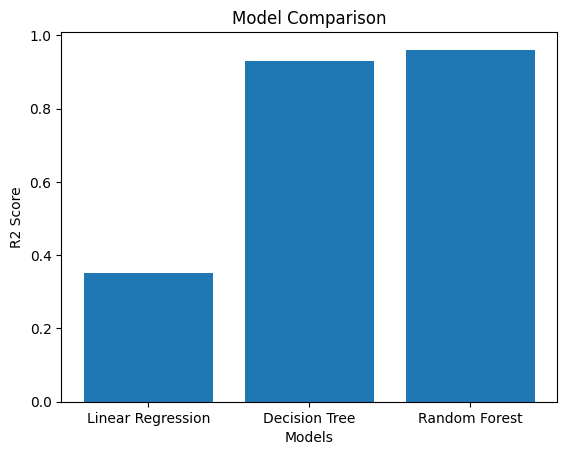

In [18]:
import matplotlib.pyplot as plt
models=["Linear Regression","Decision Tree","Random Forest"]
r2_scores = [r2_lr, r2_dt, r2_rf]

plt.figure()
plt.bar(models, r2_scores)

plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.title("Model Comparison")

plt.show()

STEP 6: Feature Importance Analysis

In [19]:
importance = RF.feature_importances_
for name, score in zip(X.columns, importance):
    print(name, ":", score)

Country Code : 0.0030842091828755715
Longitude : 0.012342426172970333
Latitude : 0.010672282055621509
Average Cost for two : 0.005106005985175566
Has Table booking : 0.0004017753133520956
Has Online delivery : 0.0008318331573078571
Is delivering now : 5.5610429395888886e-05
Switch to order menu : 0.0
Price range : 0.0006541338320546085
Votes : 0.9452652300196419
City_Abu Dhabi : 1.1774363592306314e-05
City_Agra : 1.0090954936722818e-05
City_Ahmedabad : 8.40959446534476e-06
City_Albany : 4.823168743819242e-06
City_Allahabad : 6.7965939147498054e-06
City_Amritsar : 2.2860778681813814e-05
City_Ankara : 2.0969314043937118e-05
City_Armidale : 2.649880399110274e-07
City_Athens : 3.226582977848785e-06
City_Auckland : 4.257054516425908e-06
City_Augusta : 8.70044037848834e-06
City_Aurangabad : 3.082154407752464e-05
City_Balingup : 5.749371811190106e-07
City_Bandung : 5.662452102774507e-07
City_Bangalore : 2.1257757740866697e-06
City_Beechworth : 0.0
City_Bhopal : 9.130325402830675e-06
City_Bhub

### CONCLUSION :
1. Random Forest was selected as the best model based on performance metrics.
2. Feature importance analysis showed that 'Votes' is the most significant factor influencing restaurant ratings, while other features have minimal impact.

